In [1]:
import pandas as pd
import numpy as np
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Trỏ đường dẫn để gọi file trong thư mục src
sys.path.append(os.path.abspath('../src'))
from dataPreprocessing import load_and_preprocess_raw

RAW_DIR = '../dataset/raw/'

# 1. Load dữ liệu thông qua hàm đóng gói (Lấy mẫu 10000 dòng để phân tích nhanh)
print("Đang tải dữ liệu...")
df = load_and_preprocess_raw(RAW_DIR, nrows=10000)

print("\nĐang tính toán phân loại nhu cầu. Quá trình này có thể mất 1-2 phút...")

# Lấy mẫu 100 sản phẩm để phân tích
sample_items = df['item_id'].unique()[:100]
df_run = df[df['item_id'].isin(sample_items)]

def classify_demand(group):
    """Hàm tính ADI, CV2 và phân loại cho từng sản phẩm"""
    demand = group['demand'].values
    if demand.sum() == 0:
        return pd.Series({'ADI': np.nan, 'CV2': np.nan, 'Category': 'No Sales'})
        
    non_zero_indices = np.where(demand > 0)[0]
    first_sale_idx = non_zero_indices[0]
    active_demand = demand[first_sale_idx:]
    
    days_with_sales = len(active_demand[active_demand > 0])
    adi = len(active_demand) / days_with_sales if days_with_sales > 0 else np.nan
        
    mean_demand = np.mean(active_demand)
    cv2 = (np.std(active_demand) / mean_demand) ** 2 if mean_demand > 0 else 0
        
    if adi <= 1.32 and cv2 <= 0.49:
        category = 'Smooth (Đều đặn)'
    elif adi <= 1.32 and cv2 > 0.49:
        category = 'Erratic (Thất thường)'
    elif adi > 1.32 and cv2 <= 0.49:
        category = 'Intermittent (Ngắt quãng)'
    else:
        category = 'Lumpy (Cục bộ)'
        
    return pd.Series({'ADI': round(adi, 2), 'CV2': round(cv2, 2), 'Category': category})

# 2. Áp dụng hàm phân loại
# Mới:
classification_df = df_run.groupby(['item_id', 'store_id'], observed=True).apply(classify_demand).reset_index()

# Lọc bỏ các món không bán được và xóa sạch các dòng NaN bóng ma
classification_df = classification_df[classification_df['Category'] != 'No Sales'].dropna()

print("\n✅ Hoàn tất! Thống kê số lượng các nhóm nhu cầu:")
print(classification_df['Category'].value_counts())

print("\nBảng phân loại chi tiết (5 dòng đầu):")
display(classification_df.head())

Đang tải dữ liệu...
1. Đang tải và ép cân dữ liệu Calendar...
2. Đang tải dữ liệu Sales...
3. Đang Melt (kéo giãn) dữ liệu Sales...
4. Đang Merge Sales với Calendar...

-> Đang xử lý Outliers (IQR) và Zeroes...
5. Ép cân lần cuối cho DataFrame tổng...

Đang tính toán phân loại nhu cầu. Quá trình này có thể mất 1-2 phút...

✅ Hoàn tất! Thống kê số lượng các nhóm nhu cầu:
Category
Lumpy (Cục bộ)           385
Erratic (Thất thường)     14
Smooth (Đều đặn)           1
Name: count, dtype: int64

Bảng phân loại chi tiết (5 dòng đầu):


,item_id,store_id,ADI,CV2,Category
0,HOBBIES_1_001,CA_1,2.40,1.959961,Lumpy (Cục bộ)
1,HOBBIES_1_001,CA_2,2.76,2.390625,Lumpy (Cục bộ)
2,HOBBIES_1_001,CA_3,2.17,1.650391,Lumpy (Cục bộ)
3,HOBBIES_1_001,CA_4,2.29,1.839844,Lumpy (Cục bộ)
4,HOBBIES_1_002,CA_1,4.40,3.400391,Lumpy (Cục bộ)


📸 Đã lưu biểu đồ Lag Chart (ACF/PACF) vào docs/images/lag_chart_acf_pacf.png


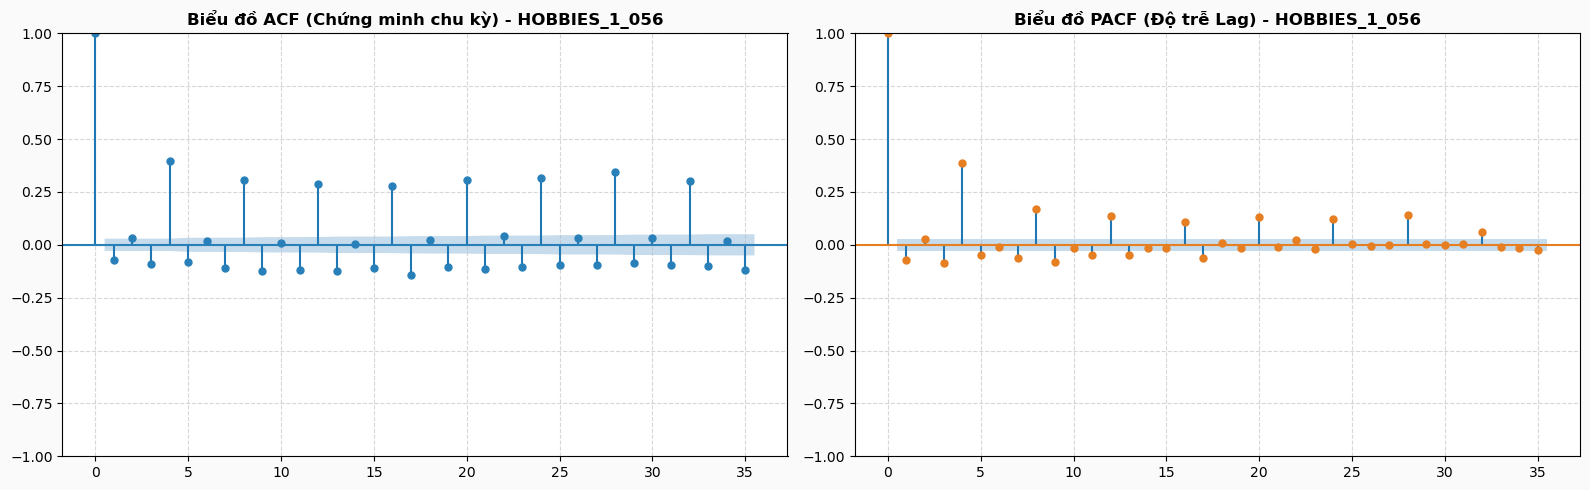

In [2]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import os

# Lấy 1 sản phẩm bán chạy nhất để vẽ biểu đồ chứng minh chu kỳ
sample_item = df_run['item_id'].value_counts().index[0]
demand_series = df_run[df_run['item_id'] == sample_item]['demand'].values

# Lọc bỏ những ngày đầu tiên chưa bán hàng (toàn số 0)
non_zero_indices = np.where(demand_series > 0)[0]
if len(non_zero_indices) > 0:
    active_demand = demand_series[non_zero_indices[0]:]
else:
    active_demand = demand_series

fig, ax = plt.subplots(1, 2, figsize=(16, 5), facecolor='#FAFAFA')

# Vẽ ACF (Tự tương quan)
plot_acf(active_demand, lags=35, ax=ax[0], color='#2980b9')
ax[0].set_title(f'Biểu đồ ACF (Chứng minh chu kỳ) - {sample_item}', fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.5)

# Vẽ PACF (Tự tương quan riêng phần)
plot_pacf(active_demand, lags=35, ax=ax[1], color='#e67e22')
ax[1].set_title(f'Biểu đồ PACF (Độ trễ Lag) - {sample_item}', fontweight='bold')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
os.makedirs('../docs/images', exist_ok=True)
plt.savefig('../docs/images/lag_chart_acf_pacf.png', dpi=300)
print("📸 Đã lưu biểu đồ Lag Chart (ACF/PACF) vào docs/images/lag_chart_acf_pacf.png")
plt.show()